# Pendulums and Damped Spring — Oscillatory and Chaotic Dynamics

## Overview

These three models form a natural family, all built on the same second-order oscillator
skeleton:

> *restoring force + optional damping + optional drive*

**`DampedSpring`** is the linear oscillator: restoring force $kx$, analytic solution known
for all damping regimes. This makes it the right starting point — resonance, phase lag, and
the frequency-response curve are all clean and exact. The drive is registered via
`register_forcing` rather than baked into the constructor.

**`SimplePendulum`** replaces $kx$ with the nonlinear restoring torque $\sin\theta$ — no
small-angle approximation. Damping is optional; the undamped case conserves energy exactly.
The nonlinearity means no closed-form solution exists for large amplitudes, and the model
behaves qualitatively differently from the spring at large swings.

**The driven pendulum** adds a periodic cosine torque $A\cos(\Omega t)$ to
$d\omega/dt$ via `register_forcing`. Because $\sin\theta$ is nonlinear, this drive
can push the system into deterministic chaos — something the spring, being linear,
can never do. Period-doublings and a strange attractor appear as $A$ increases.

All three share the same PaleoBeasts API, use `uses_post_history=True`, and provide
`natural_frequency()`, `natural_period()`, and `damping_ratio()` convenience methods.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import climatecritters as cc
from climatecritters.signal_models.damped_spring import DampedSpring
from climatecritters.signal_models.pendulum import SimplePendulum

## Spring

### DampedSpring: free decay

$$
\begin{aligned}
\frac{dx}{dt} &= v \\
\frac{dv}{dt} &= -\frac{c}{m}\,v - \frac{k}{m}\,x + \frac{F(t)}{m}
\end{aligned}
$$

Linear restoring force $kx$ makes this system analytically tractable — the exact solution
for $F=0$ is known for all damping regimes. Unlike the pendulum, there is no route to chaos
for periodic $F(t)$: the response is always periodic at the drive frequency plus a decaying transient.


#### Parameters

| Parameter | Description | Default |
|-----------|-------------|--------|
| `m` | Mass (kg) | 1.0 |
| `k` | Spring constant (N/m) | 1.0 |
| `c` | Damping coefficient (N·s/m) | 0.1 |
| `F` | External force (N); can be a `Forcing` | 0.0 |

**Diagnostics:** `energy` ($\frac{1}{2}mv^2 + \frac{1}{2}kx^2$), `omega_0` ($\sqrt{k/m}$).


#### Damping regimes

The damping ratio $\zeta = c / (2\sqrt{km})$ classifies the qualitative response:

| $\zeta$ | Regime | Behaviour |
|---------|--------|----------|
| 0 | Undamped | Perpetual oscillation; energy conserved |
| $0 < \zeta < 1$ | Underdamped | Decaying oscillations |
| $\zeta = 1$ | Critically damped | Fastest non-oscillatory return to equilibrium |
| $\zeta > 1$ | Overdamped | Slow non-oscillatory decay |

In [2]:
m_kg, k_spring = 1.0, 4.0   # ω₀ = 2 rad/s, T₀ = π ≈ 3.14 s

spring_under = DampedSpring(m=m_kg, k=k_spring, c=0.4)
spring_over  = DampedSpring(m=m_kg, k=k_spring, c=4.5)

out_under = spring_under.integrate(t_span=(0, 20), y0=[1.0, 0.0], method='RK45')
out_over  = spring_over.integrate(t_span=(0, 20),  y0=[1.0, 0.0], method='RK45')

print(f'c=0.4 → ζ = {spring_under.damping_ratio():.3f}  (underdamped)')
print(f'c=4.5 → ζ = {spring_over.damping_ratio():.3f}  (overdamped)')
print(f'ω₀ = {spring_under.natural_frequency():.3f} rad/s,  T₀ = {spring_under.natural_period():.3f} s')

c=0.4 → ζ = 0.100  (underdamped)
c=4.5 → ζ = 1.125  (overdamped)
ω₀ = 2.000 rad/s,  T₀ = 3.142 s


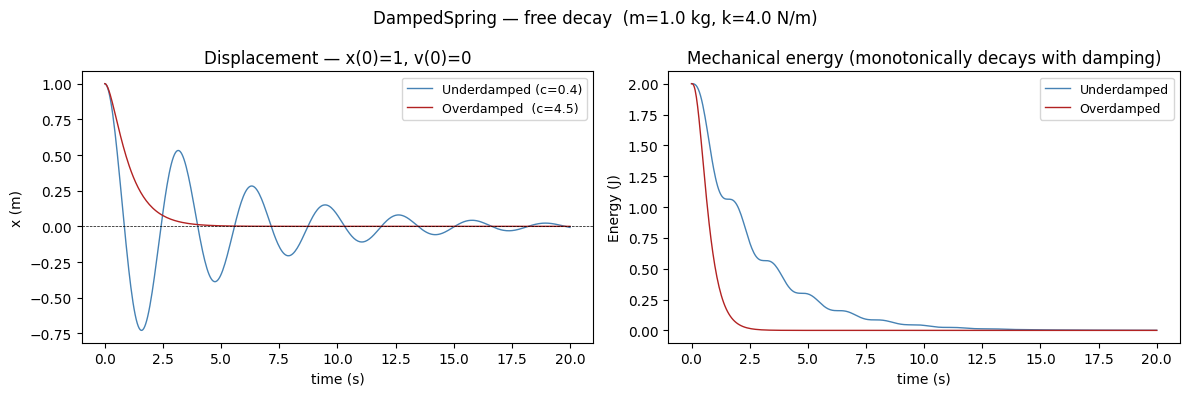

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_u = np.asarray(out_under.time)
t_o = np.asarray(out_over.time)
axes[0].plot(t_u, out_under.state_variables['x'], color='steelblue', lw=1.0, label='Underdamped (c=0.4)')
axes[0].plot(t_o, out_over.state_variables['x'],  color='firebrick', lw=1.0, label='Overdamped  (c=4.5)')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('x (m)')
axes[0].set_title('Displacement — x(0)=1, v(0)=0')
axes[0].legend(fontsize=9)

axes[1].plot(t_u, out_under.diagnostic_variables['energy'], color='steelblue', lw=1.0, label='Underdamped')
axes[1].plot(t_o, out_over.diagnostic_variables['energy'],  color='firebrick', lw=1.0, label='Overdamped')
axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('Energy (J)')
axes[1].set_title('Mechanical energy (monotonically decays with damping)')
axes[1].legend(fontsize=9)

fig.suptitle(f'DampedSpring — free decay  (m={m_kg} kg, k={k_spring} N/m)')
plt.tight_layout(); plt.show()

**Figure.** Left: displacement $x(t)$ for four damping regimes starting from $x_0=1$, $v_0=0$. Underdamped ($\zeta < 1$) rings down through oscillations; critically damped returns to zero fastest without overshoot; overdamped creeps back slowly. Right: mechanical energy decays monotonically in all damped cases — the rate reflects $\zeta$. Undamped energy is exactly constant (numerical error at the $10^{-7}$ level).

### DampedSpring: periodic drive and frequency response

$$
X(\omega_d) = \frac{F_0/m}{\sqrt{(\omega_0^2 - \omega_d^2)^2 + (c\,\omega_d/m)^2}}
$$

At **resonance** ($\omega_d = \omega_0$) the denominator is minimised and the steady-state amplitude is largest. In the undamped limit the amplitude grows without bound (secular growth). Time-varying drives attach via `register_forcing`:

```python
model.register_forcing('F', cc.core.Forcing(lambda t: F0 * np.cos(omega_d * t)))
```

#### Sub-resonant, resonant, and super-resonant drive

In [4]:
omega0_s = np.sqrt(k_spring / m_kg)   # = 2 rad/s
F0 = 1.0
c_drive = 0.4   # light damping — bounded resonant peak

drive_cases = [
    (0.5 * omega0_s, f'Sub-resonant  (ωd = ω₀/2 = {0.5*omega0_s:.2f})',  'steelblue'),
    (omega0_s,       f'Resonant      (ωd = ω₀   = {omega0_s:.2f})',       'firebrick'),
    (2.0 * omega0_s, f'Super-resonant(ωd = 2ω₀  = {2.0*omega0_s:.2f})',   'goldenrod'),
]

models_drv = []
for omega_d, label, color in drive_cases:
    m = DampedSpring(m=m_kg, k=k_spring, c=c_drive)
    m.register_forcing('F', cc.core.Forcing(lambda t, wd=omega_d: F0 * np.cos(wd * t)))
    out = m.integrate(t_span=(0, 60), y0=[0.0, 0.0], method='RK45')
    models_drv.append(out)
    # steady-state amplitude (post-transient mean peak)
    t_arr = np.asarray(out.time)
    x_ss = out.state_variables['x'][t_arr > 30]
    print(f'{label}  →  max|x|_ss = {np.max(np.abs(x_ss)):.3f} m')

Sub-resonant  (ωd = ω₀/2 = 1.00)  →  max|x|_ss = 0.331 m
Resonant      (ωd = ω₀   = 2.00)  →  max|x|_ss = 1.250 m
Super-resonant(ωd = 2ω₀  = 4.00)  →  max|x|_ss = 0.083 m


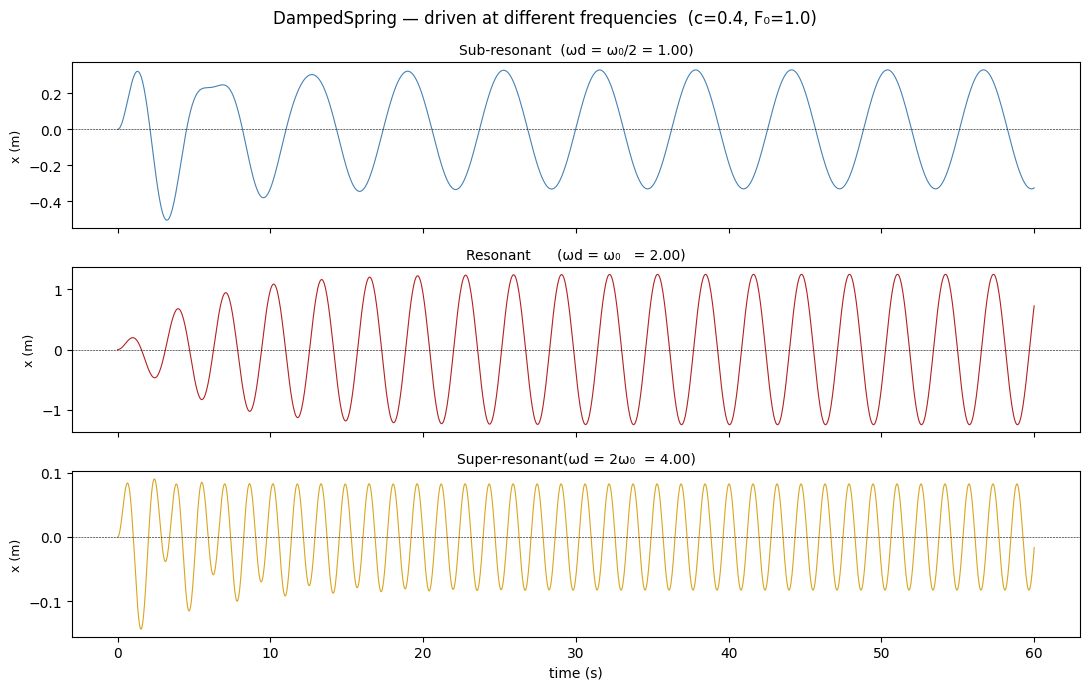

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

for ax, out, (omega_d, label, color) in zip(axes, models_drv, drive_cases):
    t = np.asarray(out.time)
    ax.plot(t, out.state_variables['x'], lw=0.8, color=color)
    ax.axhline(0, color='k', lw=0.4, ls='--')
    ax.set_ylabel('x (m)', fontsize=9)
    ax.set_title(label, fontsize=10)

axes[-1].set_xlabel('time (s)')
fig.suptitle(f'DampedSpring — driven at different frequencies  (c={c_drive}, F₀={F0})')
plt.tight_layout(); plt.show()

**Figure.** Displacement $x(t)$ for drive frequencies below, at, and above natural frequency $\omega_0 = 2$ rad/s. Sub-resonant: small in-phase oscillations. Resonant: amplitude grows during the transient before settling to the largest steady-state value. Super-resonant: small out-of-phase oscillations — the mass can't follow the fast drive.

#### Resonance curve: steady-state amplitude vs drive frequency

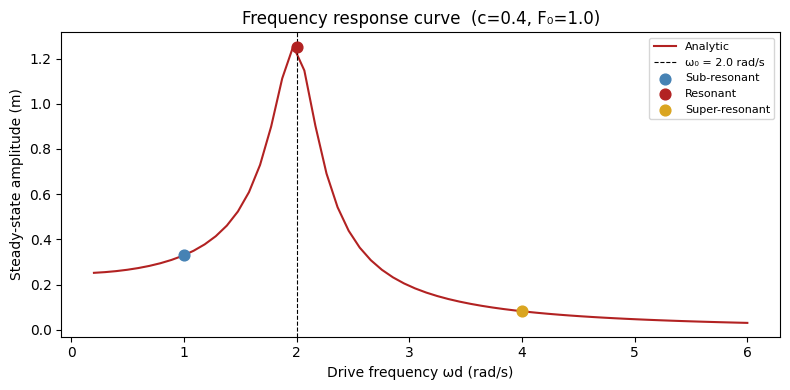

In [6]:
omega_d_vals = np.linspace(0.2, 6.0, 60)

# Analytic steady-state amplitude
X_analytic = (F0 / m_kg) / np.sqrt(
    (omega0_s**2 - omega_d_vals**2)**2 + (c_drive * omega_d_vals / m_kg)**2
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(omega_d_vals, X_analytic, color='firebrick', lw=1.5, label='Analytic')
ax.axvline(omega0_s, color='k', lw=0.8, ls='--', label=f'\u03c9\u2080 = {omega0_s:.1f} rad/s')

# Overlay the three numerical steady-state points
for out, (omega_d, label, color) in zip(models_drv, drive_cases):
    t_arr = np.asarray(out.time)
    x_ss = out.state_variables['x'][t_arr > 30]
    ax.scatter([omega_d], [np.max(np.abs(x_ss))], color=color, s=60, zorder=5,
               label=label.split('(')[0].strip())

ax.set_xlabel('Drive frequency \u03c9d (rad/s)')
ax.set_ylabel('Steady-state amplitude (m)')
ax.set_title(f'Frequency response curve  (c={c_drive}, F\u2080={F0})')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Pendulum

### SimplePendulum

$$
\begin{aligned}
\frac{d\theta}{dt} &= \omega \\
\frac{d\omega}{dt} &= -\lambda\,\omega - \omega_0^2\,\sin\theta, \qquad \omega_0 = \sqrt{g/L}
\end{aligned}
$$

No small-angle approximation — the restoring torque is the exact $\sin\theta$. Setting `damping=0` gives the conservative nonlinear pendulum; energy is then an exact constant of motion.

#### Parameters

| Parameter | Description | Default |
|-----------|-------------|--------|
| `L` | Rod length (m) | 1.0 |
| `g` | Gravitational acceleration (m/s²) | 9.81 |
| `damping` | Linear damping coefficient $\lambda$ (s⁻¹) | 0.0 |

**Diagnostics:** `energy` ($\frac{1}{2}(L\omega)^2 + gL(1-\cos\theta)$), `omega_0` ($\sqrt{g/L}$).

#### Damping regimes

The damping ratio $\zeta = \lambda / (2\omega_0)$ classifies the response (same regimes as the spring):

| $\zeta$ | Regime | Behaviour |
|---------|--------|----------|
| 0 | Undamped | Perpetual oscillation; energy conserved |
| $0 < \zeta < 1$ | Underdamped | Decaying oscillations |
| $\zeta = 1$ | Critically damped | Fastest non-oscillatory return |
| $\zeta > 1$ | Overdamped | Slow non-oscillatory decay |

In [7]:
# L=1 m, g=9.81 m/s² → ω₀ ≈ 3.13 rad/s, T₀ ≈ 2.01 s
L, g = 1.0, 9.81
omega0 = np.sqrt(g / L)
lam_crit = 2.0 * omega0   # critical damping: λ = 2ω₀

damping_cases = [
    (0.0,        'Undamped  (ζ=0)',          'steelblue'),
    (1.0,        f'Underdamped  (ζ={1.0/(2*omega0):.2f})', 'seagreen'),
    (lam_crit,   'Critically damped  (ζ=1)', 'firebrick'),
    (2*lam_crit, 'Overdamped  (ζ=2)',        'goldenrod'),
]

theta0 = np.pi / 2   # 90° — large enough to show nonlinear effects

models_sp = []
for lam, label, _ in damping_cases:
    m = SimplePendulum(L=L, g=g, damping=lam)
    out = m.integrate(t_span=(0, 10), y0=[theta0, 0.0], method='RK45')
    models_sp.append(out)

# Convenience helpers
m_ex = SimplePendulum(L=L, g=g, damping=lam_crit)
print(f'ω₀ = {m_ex.natural_frequency():.3f} rad/s')
print(f'T₀ = {m_ex.natural_period():.3f} s  (small-angle)')
print(f'ζ  = {m_ex.damping_ratio():.3f}  (critical → ζ=1)')

ω₀ = 3.132 rad/s
T₀ = 2.006 s  (small-angle)
ζ  = 1.000  (critical → ζ=1)


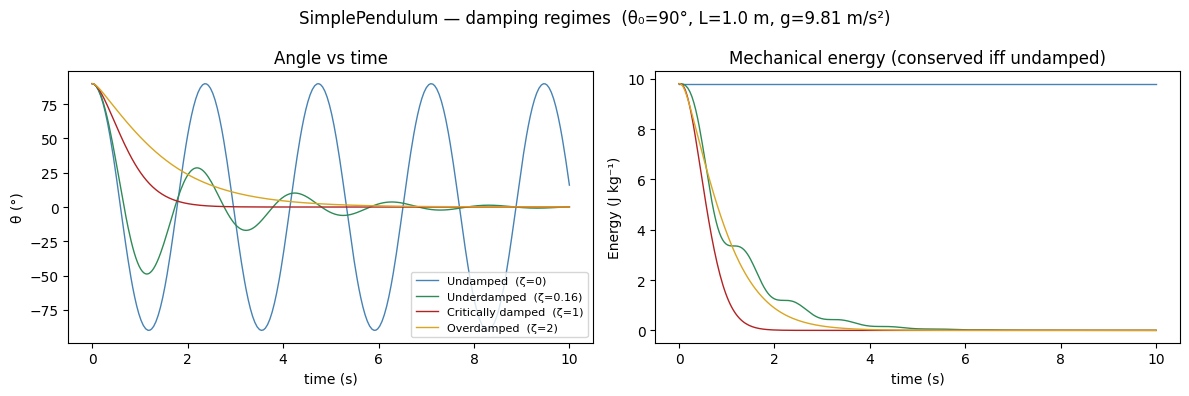

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for out, (lam, label, color) in zip(models_sp, damping_cases):
    t = np.asarray(out.time)
    axes[0].plot(t, np.degrees(out.state_variables['theta']), lw=1.0, color=color, label=label)
    axes[1].plot(t, out.diagnostic_variables['energy'], lw=1.0, color=color)

axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('θ (°)')
axes[0].set_title('Angle vs time')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('time (s)'); axes[1].set_ylabel('Energy (J kg⁻¹)')
axes[1].set_title('Mechanical energy (conserved iff undamped)')

fig.suptitle(f'SimplePendulum — damping regimes  (θ₀=90°, L={L} m, g={g} m/s²)')
plt.tight_layout(); plt.show()

**Figure.** Left: $\theta(t)$ for four damping regimes starting from $\theta_0 = 90°$. The large initial angle means nonlinear effects are visible — the undamped period is longer than the small-angle prediction $T_0 = 2\pi/\omega_0$. Right: energy is exactly conserved for the undamped case; damped cases decay at rates set by $\zeta$.

### Driven Pendulum

Dimensionless form ($g = L = m = 1$, so $\omega_0 = 1$):

$$
\begin{aligned}
\frac{d\theta}{dt} &= \omega \\
\frac{d\omega}{dt} &= -q\,\omega - \sin\theta + A\cos(\Omega t)
\end{aligned}
$$

The $\sin\theta$ nonlinearity is what distinguishes this from the spring — it allows the periodic drive to push the system into chaos. The spring's linear $kx$ restoring force can never produce a strange attractor, no matter how large the drive.

#### Parameters and implementation

| Parameter | Description | Value used |
|-----------|-------------|----------|
| `q` | Damping coefficient | 0.5 |
| `A` | Drive amplitude | 0.5 / 1.07 / 1.2 |
| `Omega` | Drive frequency | 2/3 |

The drive is attached to `SimplePendulum` via additive forcing on $\omega$:

```python
m = SimplePendulum(L=1.0, g=1.0, damping=q)
m.register_forcing('omega',
                   cc.core.Forcing(lambda t, A=A_val: A * np.cos(Omega * t)),
                   'additive', timing='pre')
```

#### Route to chaos  (q=0.5, Ω=2/3)

In [9]:
q, Omega = 0.5, 2.0 / 3.0
A_cases = [(0.5,  'Period-1  (A=0.5)',  'steelblue'),
           (1.07, 'Period-2  (A=1.07)', 'goldenrod'),
           (1.2,  'Chaos     (A=1.2)',  'firebrick')]

models_dp = []
for A_val, _, _ in A_cases:
    m = SimplePendulum(L=1.0, g=1.0, damping=q)
    m.register_forcing('omega',
                       cc.core.Forcing(lambda t, A=A_val: A * np.cos(Omega * t)),
                       'additive', timing='pre')
    out = m.integrate(t_span=(0, 300), y0=[0.0, 0.0], method='RK45')
    models_dp.append(out)

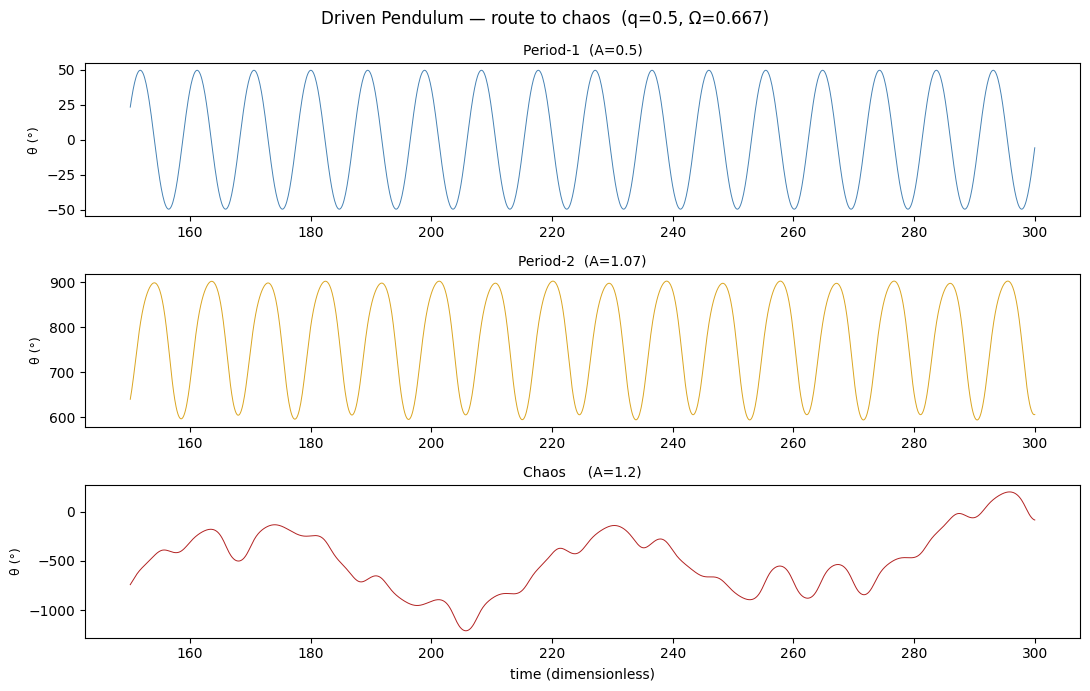

In [10]:
# Post-transient only (t > 150)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=False)

for ax, out, (A_val, label, color) in zip(axes, models_dp, A_cases):
    t = np.asarray(out.time)
    mask = t >= 150.0
    ax.plot(t[mask], np.degrees(out.state_variables['theta'][mask]),
            lw=0.7, color=color)
    ax.set_ylabel('θ (°)', fontsize=9)
    ax.set_title(label, fontsize=10)

axes[-1].set_xlabel('time (dimensionless)')
fig.suptitle(f'Driven Pendulum — route to chaos  (q={q}, Ω={Omega:.3f})')
plt.tight_layout(); plt.show()

**Figure.** Post-transient $\theta(t)$ for three drive amplitudes. Period-1 ($A=0.5$): steady oscillation at the drive frequency. Period-2 ($A=1.07$): every other cycle is slightly different — the period has doubled. Chaos ($A=1.2$): no cycle ever repeats; the system has passed through the full period-doubling cascade to a strange attractor.

#### Phase portrait — chaotic attractor (A=1.2)

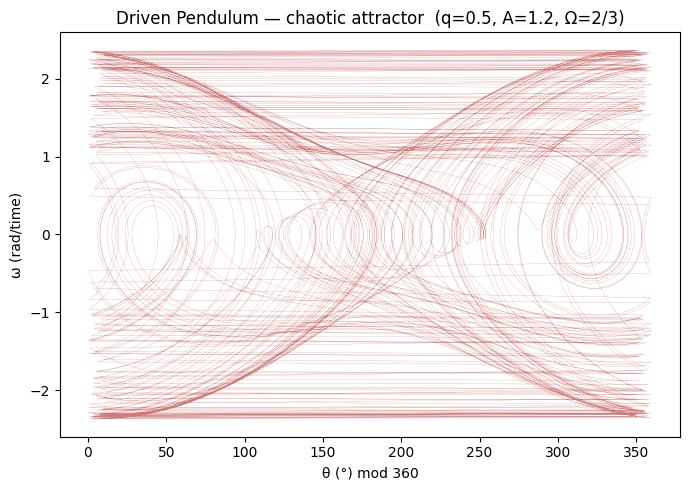

In [11]:
# Long run to fill the attractor
m_chaos = SimplePendulum(L=1.0, g=1.0, damping=q)
m_chaos.register_forcing('omega',
                          cc.core.Forcing(lambda t: 1.2 * np.cos(Omega * t)),
                          'additive', timing='pre')
out_chaos = m_chaos.integrate(t_span=(0, 1000), y0=[0.0, 0.0], method='RK45')

t_c = np.asarray(out_chaos.time)
mask_c = t_c > 100.0   # discard transient
theta_c = out_chaos.state_variables['theta'][mask_c]
omega_c = out_chaos.state_variables['omega'][mask_c]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.degrees(theta_c) % 360, omega_c, lw=0.15, color='firebrick', alpha=0.6)
ax.set_xlabel('θ (°) mod 360'); ax.set_ylabel('ω (rad/time)')
ax.set_title('Driven Pendulum — chaotic attractor  (q=0.5, A=1.2, Ω=2/3)')
plt.tight_layout(); plt.show()

## Solver notes

`RK45` is appropriate for all models at default parameters. None are stiff.

**`uses_post_history=True` on all models.** Diagnostics (`energy`, `omega_0`, `drive`)
are computed by replaying the full state history after integration.

**`DampedSpring` takes any `(t)` callable via `register_forcing`.** Use the default-argument
capture idiom when building several models in a loop:
```python
for wd in drive_freqs:
    m = DampedSpring(...)
    m.register_forcing('F', cc.core.Forcing(lambda t, wd=wd: F0 * np.cos(wd * t)))
```

**The driven pendulum** is implemented as `SimplePendulum(L=1, g=1, damping=q)` with
`register_forcing('omega', Forcing(lambda t, A=A: A*cos(Ω*t)), 'additive', timing='pre')`.
Use the default-argument capture `A=A_val` in the lambda when building models in a loop —
without it, all models will close over the final value of `A_val`.

**Energy is not conserved in driven or damped cases.** The `energy` diagnostic records
instantaneous mechanical energy; in a driven system it fluctuates at the drive frequency
in steady state.